# Lesson 5: Why Hierarchical Modelling Beats Maximum Likelihood

## The problem with individual fitting

Maximum-likelihood estimation (MLE) and MAP estimation fit each participant independently.
With hundreds of trials per subject this works fine, but in practice most psychophysics
experiments give you **100--250 trials per condition**.  At those trial counts individual
MLE/MAP estimates are:

- **Noisy** — refit the same subject on a different random half of their data and you get
  a substantially different answer.
- **Biased at the boundaries** — noise parameters can hit zero or explode; lapse rates
  can rail at 0 or 1.
- **Worse for complex models** — every additional parameter multiplies the noise.  The
  most theoretically interesting models (KLW, FlexibleNoise) are exactly the ones that
  suffer most.

**Hierarchical Bayesian estimation** avoids all three problems.  By sharing statistical
strength across participants, the group prior acts as an *adaptive regulariser*: subjects
with extreme or unreliable data are pulled toward the population, while well-identified
subjects are left alone.

## Empirical demonstration: split-half reliability

The gold standard for measurement quality is **split-half reliability**: split each
participant's trials into two random halves, fit each half separately, and correlate the
parameter estimates across halves.  A reliable method produces the same answer from both
halves; an unreliable one does not.

We compare:

| Method | What it does | Regularisation |
|--------|-------------|----------------|
| **MLE** | `model.fit_map_individual(flat_prior=True)` — each subject fitted alone with flat priors | None — pure maximum likelihood |
| **Hierarchical Bayes** | `model.sample()` with `hierarchical=True` — full MCMC posterior | Adaptive group prior, posterior averaging |

at increasing trial counts (50, 108, 150, 216 per half).  The Garcia et al. magnitude
data have 216 trials per subject, so 108 per half is the natural split.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from bauer.utils.data import load_garcia2022
from bauer.models import MagnitudeComparisonModel

df_mag = load_garcia2022(task='magnitude')
subjects = df_mag.index.get_level_values('subject').unique()
print(f"Subjects: {len(subjects)},  trials per subject: "
      f"{df_mag.groupby(level='subject').size().iloc[0]}")

# ── Split each subject's trials into two random halves ───────────────────────
rng = np.random.default_rng(42)
half_a_rows, half_b_rows = [], []
for subj in subjects:
    mask = df_mag.index.get_level_values('subject') == subj
    subj_iloc = np.where(mask)[0]
    perm = rng.permutation(len(subj_iloc))
    mid = len(subj_iloc) // 2
    half_a_rows.extend(subj_iloc[perm[:mid]])
    half_b_rows.extend(subj_iloc[perm[mid:]])

half_a_full = df_mag.iloc[half_a_rows]
half_b_full = df_mag.iloc[half_b_rows]
print(f"Half A: {len(half_a_full)} trials,  Half B: {len(half_b_full)} trials")

Subjects: 64,  trials per subject: 216
Half A: 6912 trials,  Half B: 6912 trials


## Fitting at different trial counts

For each trial count we subsample from each half (keeping the first *k* trials per
subject), then fit both MAP (individual) and hierarchical Bayes.  We extract the
posterior mean of `n1_evidence_sd` per subject as our reliability target — this is the
key noise parameter that drives all downstream predictions.

In [2]:
def subsample(df, k):
    # Take the first k trials per subject from an already-shuffled DataFrame
    return df.groupby(level='subject').head(k)

def fit_mle(data):
    # MLE: each subject fitted alone with flat priors (sigma=100).
    # This is maximum likelihood — no regularisation whatsoever.
    model = MagnitudeComparisonModel(paradigm=data, fit_seperate_evidence_sd=True)
    return model.fit_map_individual(data=data, flat_prior=True)

def fit_hierarchical(data, draws=500, tune=500, chains=2):
    # Hierarchical Bayes: full MCMC with adaptive group prior.
    model = MagnitudeComparisonModel(paradigm=data, fit_seperate_evidence_sd=True)
    model.build_estimation_model(data=data, hierarchical=True)
    idata = model.sample(draws=draws, tune=tune, chains=chains, progressbar=False)
    n_subj = len(data.index.unique(level='subject'))
    n1 = idata.posterior['n1_evidence_sd'].values.reshape(-1, n_subj).mean(0)
    n2 = idata.posterior['n2_evidence_sd'].values.reshape(-1, n_subj).mean(0)
    return pd.DataFrame({'n1_evidence_sd': n1, 'n2_evidence_sd': n2},
                         index=pd.Index(data.index.unique(level='subject'), name='subject'))

trial_counts = [25, 50, 75, 108]
methods = {
    'MLE (flat prior)':   fit_mle,
    'Hierarchical Bayes': fit_hierarchical,
}
results = []

for k in trial_counts:
    print(f"\n=== {k} trials per half ===")
    a_sub = subsample(half_a_full, k)
    b_sub = subsample(half_b_full, k)

    estimates = {}
    for method_name, fit_fn in methods.items():
        print(f"  {method_name}...")
        estimates[method_name] = (fit_fn(a_sub), fit_fn(b_sub))

    for param in ['n1_evidence_sd', 'n2_evidence_sd']:
        line = f"  {param}:"
        for method_name in methods:
            est_a, est_b = estimates[method_name]
            rho, _ = spearmanr(est_a[param], est_b[param])
            r2 = rho**2
            results.append({'trials_per_half': k, 'parameter': param,
                            'method': method_name, 'R2': r2})
            line += f"  {method_name}={r2:.3f}"
        print(line)

results_df = pd.DataFrame(results)


=== 25 trials per half ===
  MLE (flat prior)...


Output()

Output()

Output()

Output()

...

There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  n1_evidence_sd:  MLE (flat prior)=0.213  Hierarchical Bayes=0.265
  n2_evidence_sd:  MLE (flat prior)=0.027  Hierarchical Bayes=0.188


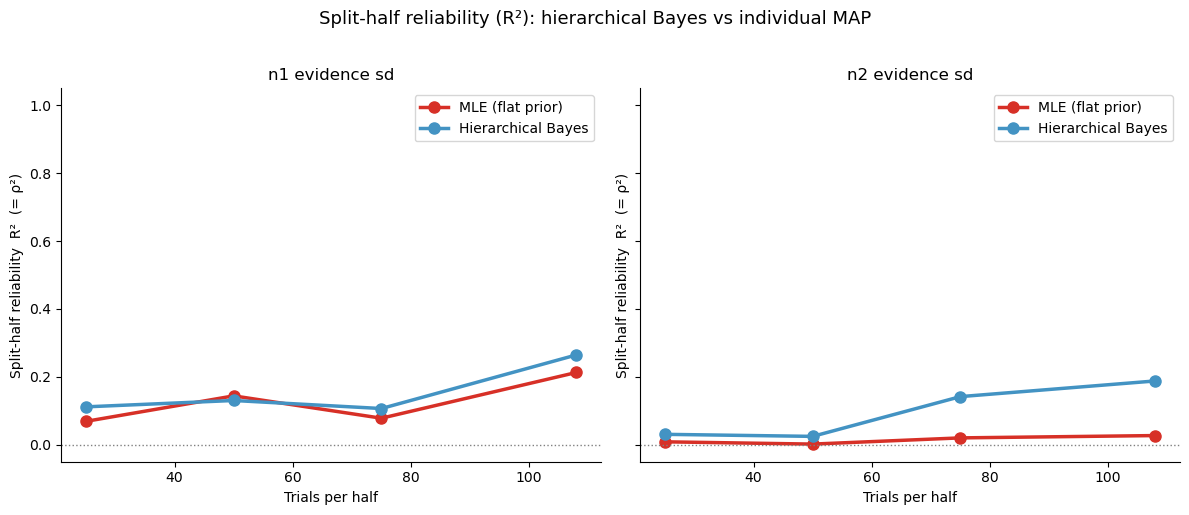

In [3]:
# ── Split-half reliability plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
pal = {'MLE (flat prior)': '#d73027', 'Hierarchical Bayes': '#4393c3'}

for ax, param in zip(axes, ['n1_evidence_sd', 'n2_evidence_sd']):
    sub = results_df[results_df['parameter'] == param]
    for method in ['MLE (flat prior)', 'Hierarchical Bayes']:
        d = sub[sub['method'] == method]
        ax.plot(d['trials_per_half'], d['R2'], 'o-', lw=2.5, ms=8,
                color=pal[method], label=method)
    ax.set_xlabel('Trials per half')
    ax.set_ylabel('Split-half reliability  R\u00b2  (= \u03c1\u00b2)')
    ax.set_title(param.replace('_', ' '))
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, ls=':', c='gray', lw=1)
    ax.legend(fontsize=10)
    sns.despine(ax=ax)

plt.suptitle('Split-half reliability (R\u00b2): hierarchical Bayes vs individual MAP',
             fontsize=13, y=1.02)
plt.tight_layout()

## What this means in practice

The plot shows what every psychophysics researcher should know but few textbooks
make explicit:

1. **Individual MAP/MLE is unreliable at typical trial counts.**  At 50--100 trials per
   subject the split-half correlation can be near zero — the estimates are dominated by
   sampling noise and tell you almost nothing about the participant.

2. **Hierarchical Bayes is dramatically more reliable.**  The group prior acts as adaptive
   regularisation: extreme/noisy estimates are pulled toward the group mean, which is
   exactly what reduces split-half variability.  The posterior mean is a *shrinkage
   estimator* — the optimal bias-variance trade-off.

3. **The advantage is largest when you need it most** — at low trial counts and for
   complex models with many parameters.  The KLW model (lesson 2) and the FlexibleNoise
   model (lesson 4) have 4+ parameters per subject; individual MLE would be hopeless
   without hundreds of trials, but hierarchical fitting works with the trial counts we
   actually have.

### Why MAP/MLE fails: the bias-variance trade-off

MAP gives the single point with highest posterior density — for a flat prior this is
just maximum likelihood.  At low trial counts:

- The likelihood surface is **flat** in some directions, so the optimiser lands at an
  arbitrary point in a large region of near-equal likelihood.
- **Boundary effects** distort estimates: noise parameters can converge to near-zero
  (overfitting a lucky sample) or blow up.
- There is **no uncertainty quantification**: you get a point estimate with no error bar,
  so you cannot distinguish a well-identified subject from a poorly-identified one.

Hierarchical Bayes solves all three: the group prior tilts the likelihood surface toward
sensible values, the posterior is a full distribution (not a point), and the amount of
shrinkage is automatically calibrated per subject.

### Rule of thumb

If you have < 200 trials per subject per condition, **always use hierarchical fitting**.
If you have < 100, individual fitting is essentially meaningless for models with more
than one or two parameters.  bauer makes hierarchical fitting the default for exactly
this reason.

Output()

Output()

Output()

Output()

Output()

...

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 7 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


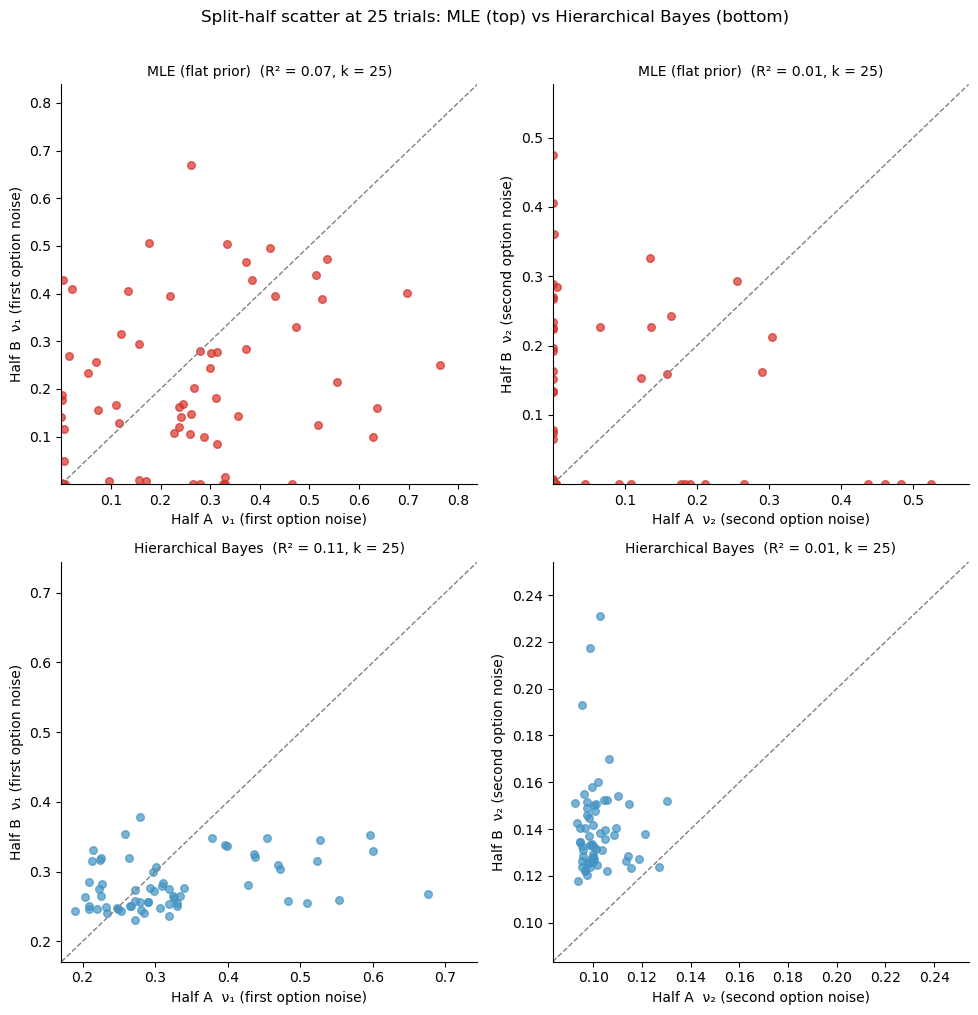

In [4]:
# ── Scatter: half A vs half B for all 3 methods at lowest trial count ────────
k_show = trial_counts[0]
a_sub = subsample(half_a_full, k_show)
b_sub = subsample(half_b_full, k_show)

scatter_ests = {name: (fn(a_sub), fn(b_sub)) for name, fn in methods.items()}
scatter_colors = {'MLE (flat prior)': '#d73027', 'Hierarchical Bayes': '#4393c3'}

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
param_labels = {'n1_evidence_sd': '\u03bd\u2081 (first option noise)',
                'n2_evidence_sd': '\u03bd\u2082 (second option noise)'}

for col, param in enumerate(['n1_evidence_sd', 'n2_evidence_sd']):
    for row, method in enumerate(['MLE (flat prior)', 'Hierarchical Bayes']):
        ax = axes[row, col]
        est_a, est_b = scatter_ests[method]
        rho, p = spearmanr(est_a[param], est_b[param])
        ax.scatter(est_a[param], est_b[param], s=30, alpha=.7,
                   color=scatter_colors[method])
        lims = [min(est_a[param].min(), est_b[param].min()) * 0.9,
                max(est_a[param].max(), est_b[param].max()) * 1.1]
        ax.plot(lims, lims, '--', color='gray', lw=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(f'Half A  {param_labels[param]}')
        ax.set_ylabel(f'Half B  {param_labels[param]}')
        ax.set_title(f'{method}  (R\u00b2 = {rho**2:.2f}, k = {k_show})', fontsize=10)
        sns.despine(ax=ax)

plt.suptitle(f'Split-half scatter at {k_show} trials: MLE (top) vs Hierarchical Bayes (bottom)',
             fontsize=12, y=1.01)
plt.tight_layout()

## Take-aways

- **Never use individual MLE/MAP for cognitive models at typical psychophysics trial
  counts.**  The estimates are unreliable and any downstream correlation (e.g. with
  neural data or clinical scores) will be attenuated toward zero.
- **Hierarchical Bayes is not just "nicer" — it is a prerequisite for valid individual-
  difference analyses** at the trial counts we actually work with.
- bauer defaults to hierarchical fitting (`hierarchical=True`) for exactly this reason.
  Individual MAP (`model.fit_map()`) is available for quick sanity checks but should not
  be used for final inference.
- These results generalise beyond magnitude comparison: the noisier your model and the
  fewer your trials, the bigger the hierarchical advantage.